<a href="https://colab.research.google.com/github/cncPomper/MMC/blob/master/MMC_lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorium 2
## Weryfikacja generatorów liczb pseudolosowych. Całkowanie metodami Monte Carlo

---

### Piotr Kitlowski
#### indeks: 303865

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import os

from scipy.stats import chi2

In [25]:
# Funkcje z laboratoria 1
def calculate_autocorrelation(series: np.array, max_lag=None):
    n = len(series)
    if n == 0:
        return np.array([])

    if max_lag is None or max_lag >= n:
        max_lag = n - 1

    mean = np.mean(series)
    centered_series = series - mean

    denominator = np.sum(centered_series**2)

    if denominator == 0:
        acorr = np.zeros(max_lag + 1)
        acorr[0] = 1.0
        return acorr

    autocorr_values = np.zeros(max_lag + 1)
    for k in range(max_lag + 1):
        if k == 0:
            autocorr_values[k] = 1.0 # Autokorelacja przy opóźnieniu 0 wynosi zawsze 1
        else:
            # Wzór: Sum((x_i - mean) * (x_{i+k} - mean)) / Sum((x_i - mean)^2)
            # Suma w liczniku obejmuje wartości od i=0 to N-k-1
            numerator = np.sum(centered_series[:-k] * centered_series[k:])
            autocorr_values[k] = numerator / denominator

    return autocorr_values

# Zdefiniuj funkcję wykreślającą autokorelację
def plot_autocorrelation(autocorr_values: np.array, title: str, original_series_length: int, requested_max_lag: int):
    plt.figure(figsize=(12, 6))

    actual_max_lag_computed = len(autocorr_values) - 1 # The highest lag value for which autocorrelation was computed
    lags = np.arange(actual_max_lag_computed + 1) # This will create lags from 0 to actual_max_lag_computed

    # Wykorzystaj funkcję plt.bar do przedstawiania wartości dyskretnych na wykresach autokorelacji szeregów czasowych
    plt.bar(lags, autocorr_values, width=0.1)

    plt.title(title, fontsize=16)
    plt.xlabel('Opóźnienie (k)', fontsize=14)
    plt.ylabel('Współczynik autokorelacji', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axhline(0, color='black', linewidth=0.8) # Linia pozioma w punkcie 0
    # Adjust xticks to use the actual_max_lag_computed
    # The step in xticks should be sensible. Let's aim for about 10 ticks.
    step = max(1, (actual_max_lag_computed + 1) // 10)
    plt.xticks(np.arange(0, actual_max_lag_computed + 1, step)) # Dostosuj podziałkę osi X, aby poprawić czytelność

    # Set x-axis limits to clearly show all bars and perhaps a bit of margin
    plt.xlim(-0.5, actual_max_lag_computed + 0.5)

    # Dodaj przedziały ufności dla sekwencji idealnie losowej (poziom ufności ok. 95%)
    # CI = +/- 2 / sqrt(N), gdzie N oznacza pierwotną długość serii
    if original_series_length > 0:
        ci = 2 / np.sqrt(original_series_length)
        plt.axhspan(-ci, ci, color='gray', alpha=0.2, label=f'95% CI (±{ci:.3f})')
        plt.legend()

    plt.tight_layout()
    plt.show()

# Zadanie 1 Generacja i podstawowa wizualizacja liczb pseudolosowych

Opis: Zadanie polega na wygenerowaniu trzech prób liczb o różnej wielkości (100, 1000 i 100000 elementów) z równomiernego rozkładu prawdopodobieństwa z przedziału od 0 do 1. Wygenerowane wartości są najpierw zapisywane do plików tekstowych, a następnie odczytywane i obrazowane za pomocą histogramów podzielonych na 10 oraz 50 przedziałów w celu porównania z teoretyczną, płaską linią rozkładu.

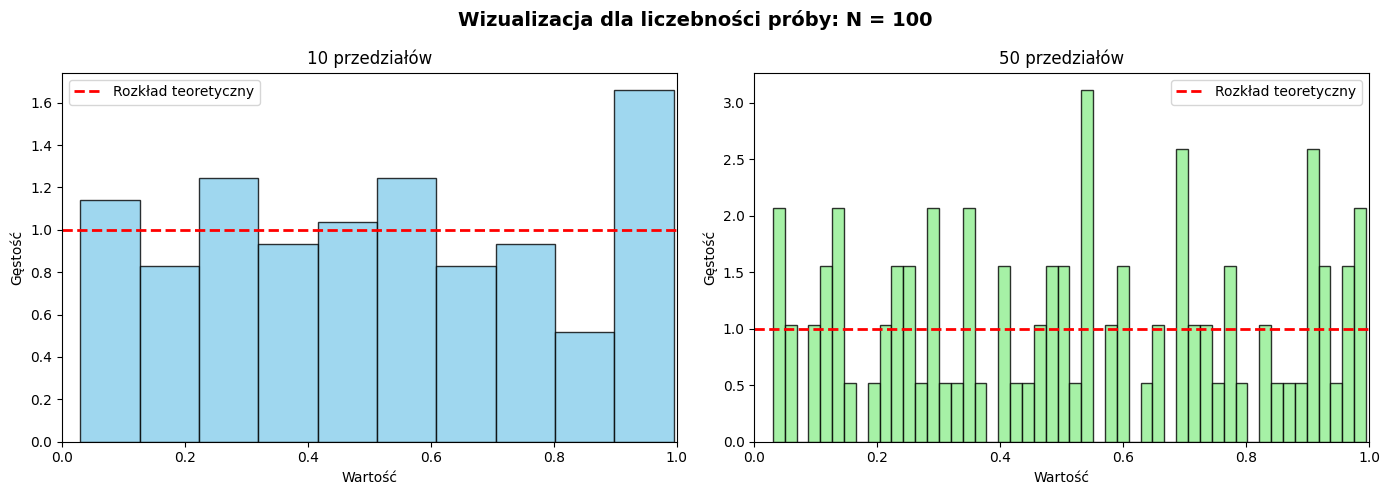

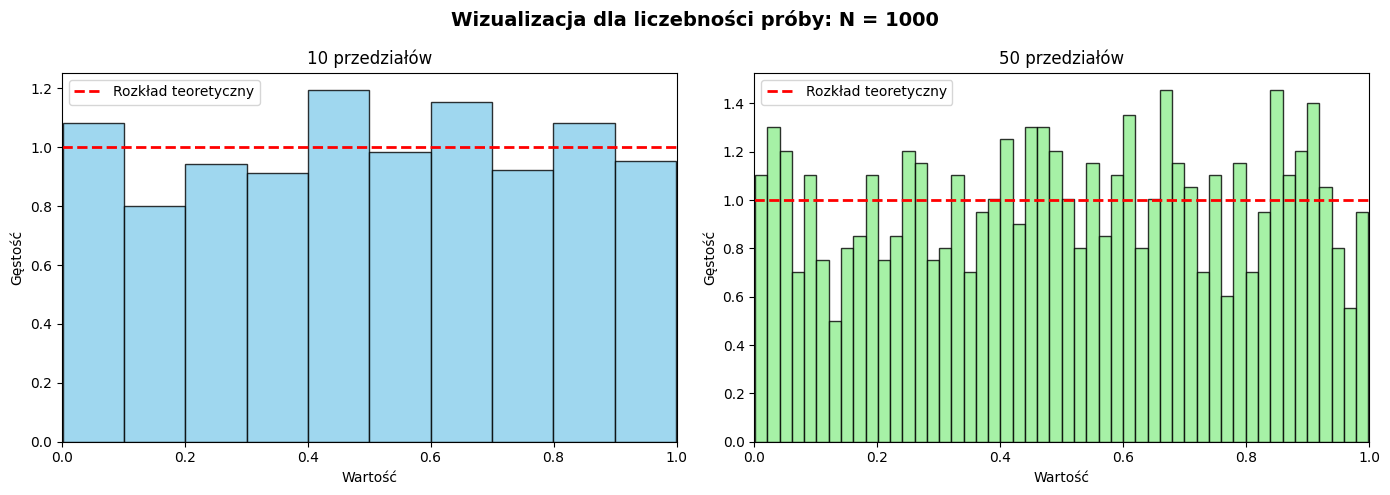

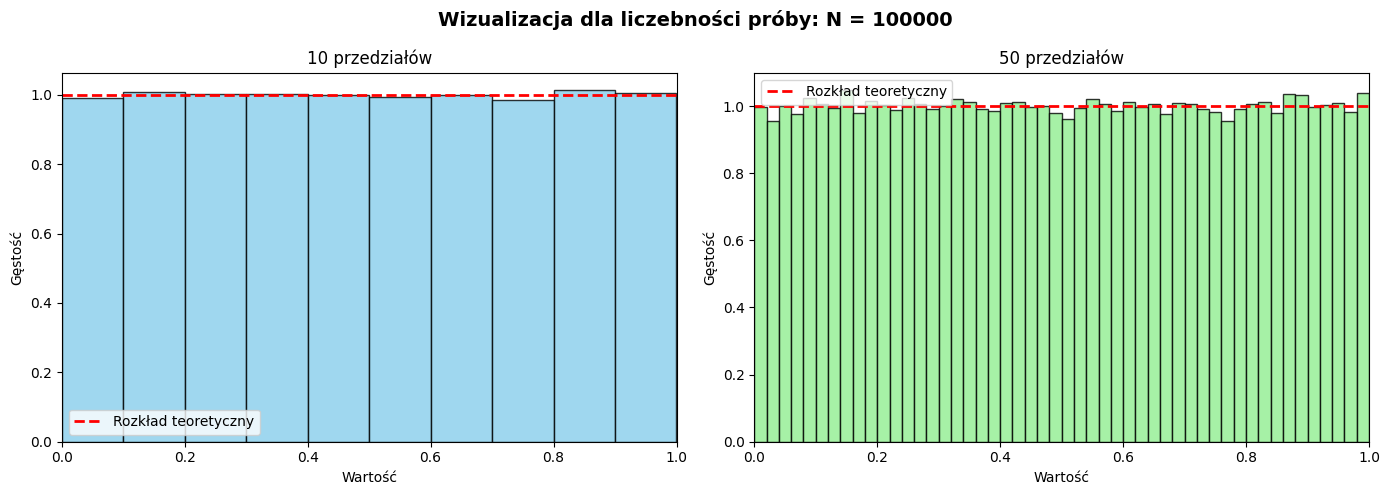

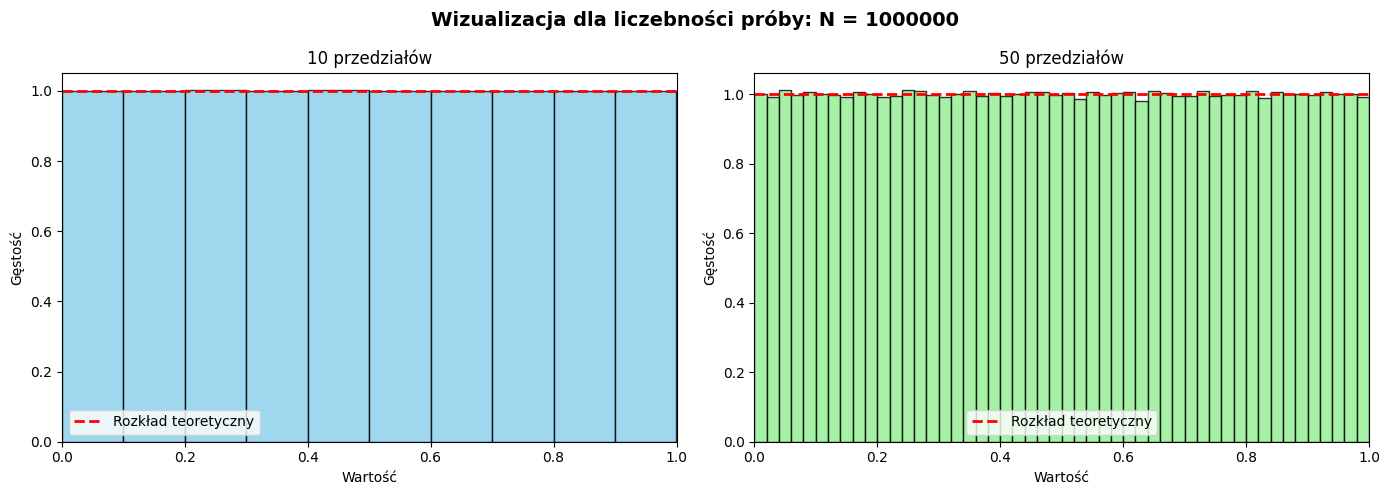

In [21]:
# Konfiguracja: różne wielkości prób, aby zaobserwować wpływ liczebności
wielkosci_prob = [100, 1000, 100000, 1_000_000]
nazwa_pliku_prefix = "liczby_losowe_"

for N in wielkosci_prob:
    nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"
    # 1. Generacja liczb z rozkładu równomiernego (od 0 do 1)
    # Odpowiednik generatora z GSL / std::random w C++
    liczby = np.random.uniform(0, 1, N)

    # 2. Zapis wygenerowanych liczb do pliku tekstowego
    np.savetxt(nazwa_pliku, liczby)

    # 3. Odczyt wygenerowanych liczb z pliku tekstowego
    liczby_z_pliku = np.loadtxt(nazwa_pliku)

    # 4. Wykreślenie histogramów
    # Używamy density=True, aby znormalizować pole pod histogramem do 1,
    # co pozwala łatwo nanieść rozkład teoretyczny (dla U(0,1) y=1)
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Wizualizacja dla liczebności próby: N = {N}", fontsize=14, fontweight='bold')

    # Rozkład teoretyczny (linia pozioma na wysokości 1)
    teoretyczny_x = [0, 1]
    teoretyczny_y = [1, 1]

    # Histogram 1 - 10 przedziałów (bins=10)
    axs[0].hist(liczby_z_pliku, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.8)
    axs[0].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[0].set_title('10 przedziałów')
    axs[0].set_xlabel('Wartość')
    axs[0].set_ylabel('Gęstość')
    axs[0].set_xlim(0, 1)
    axs[0].legend()

    # Histogram 2 - 50 przedziałów (bins=50)
    axs[1].hist(liczby_z_pliku, bins=50, density=True, color='lightgreen', edgecolor='black', alpha=0.8)
    axs[1].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[1].set_title('50 przedziałów')
    axs[1].set_xlabel('Wartość')
    axs[1].set_ylabel('Gęstość')
    axs[1].set_xlim(0, 1)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

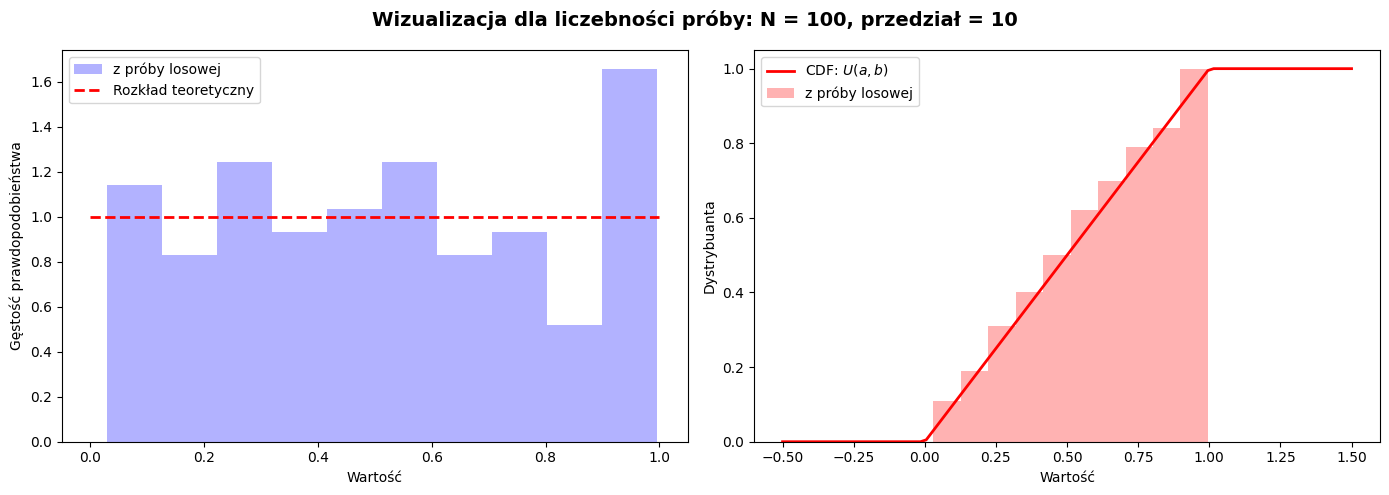

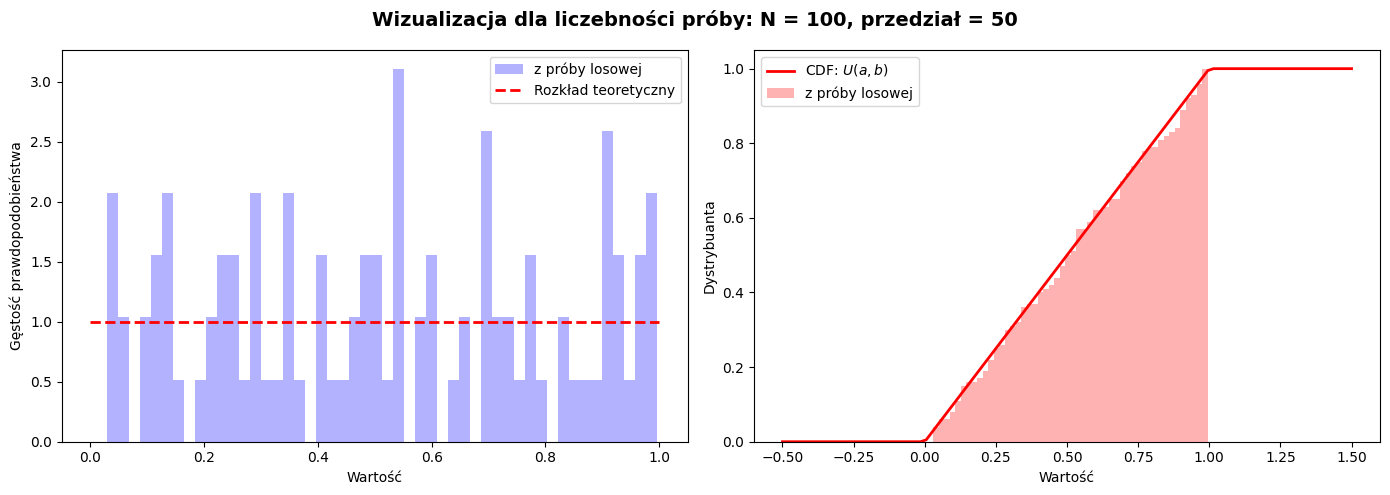

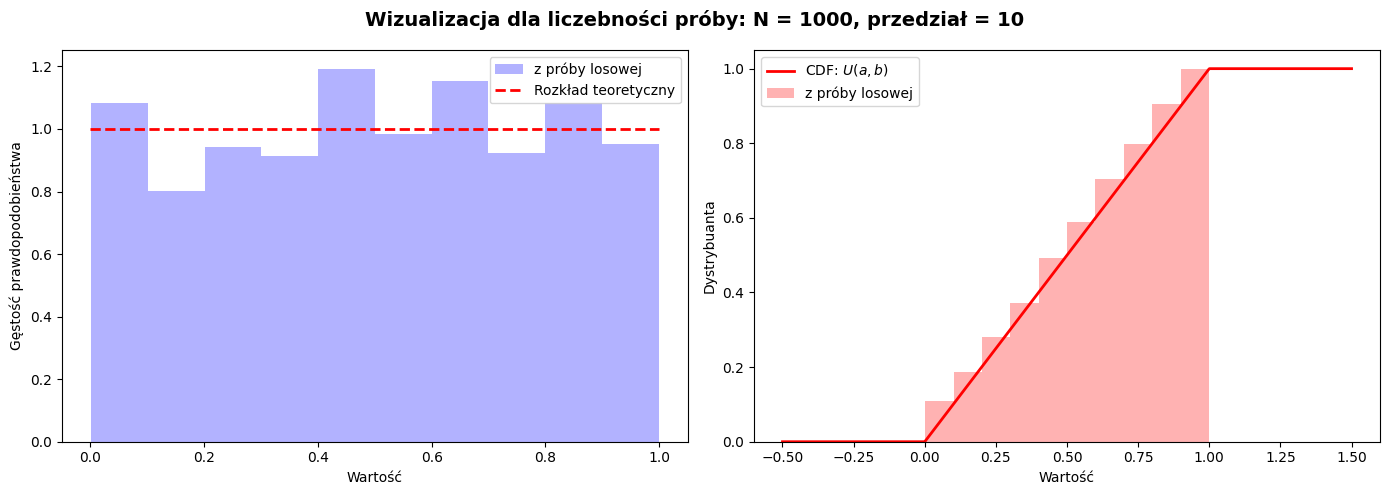

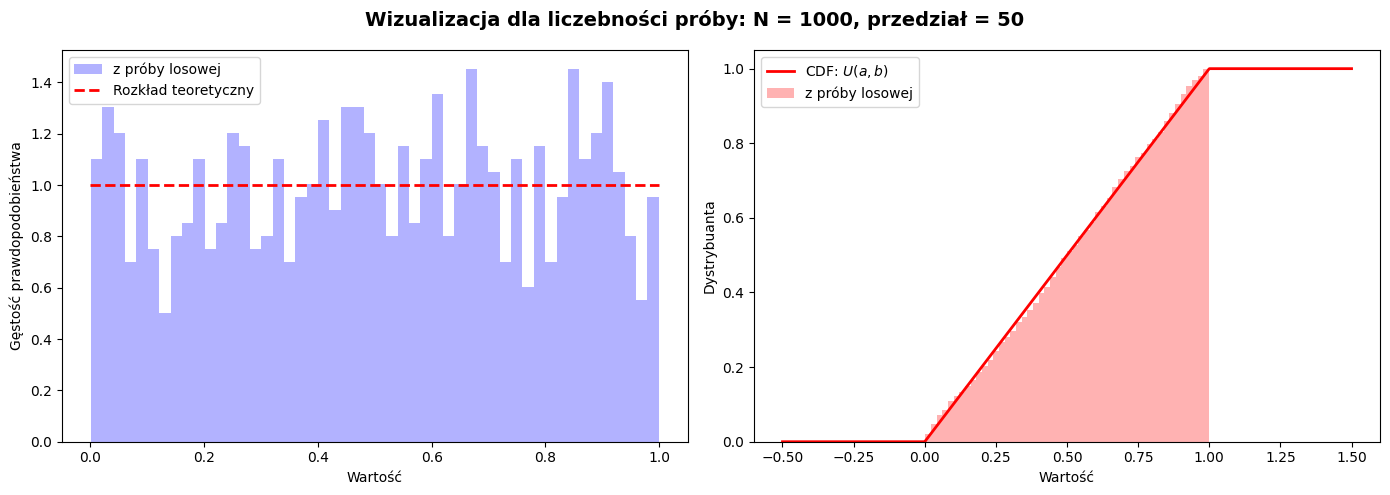

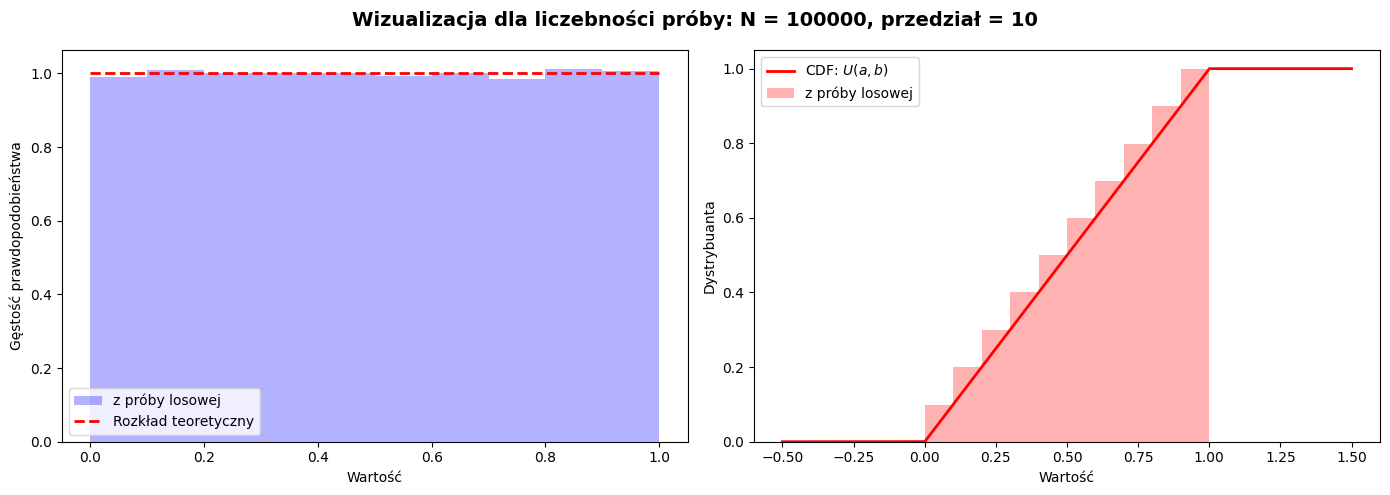

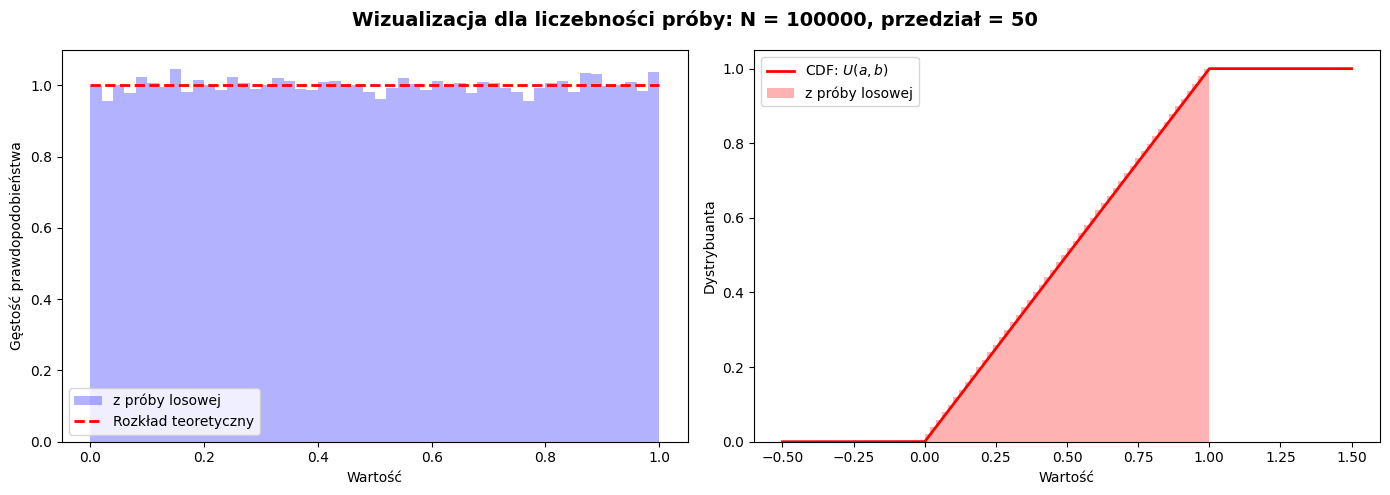

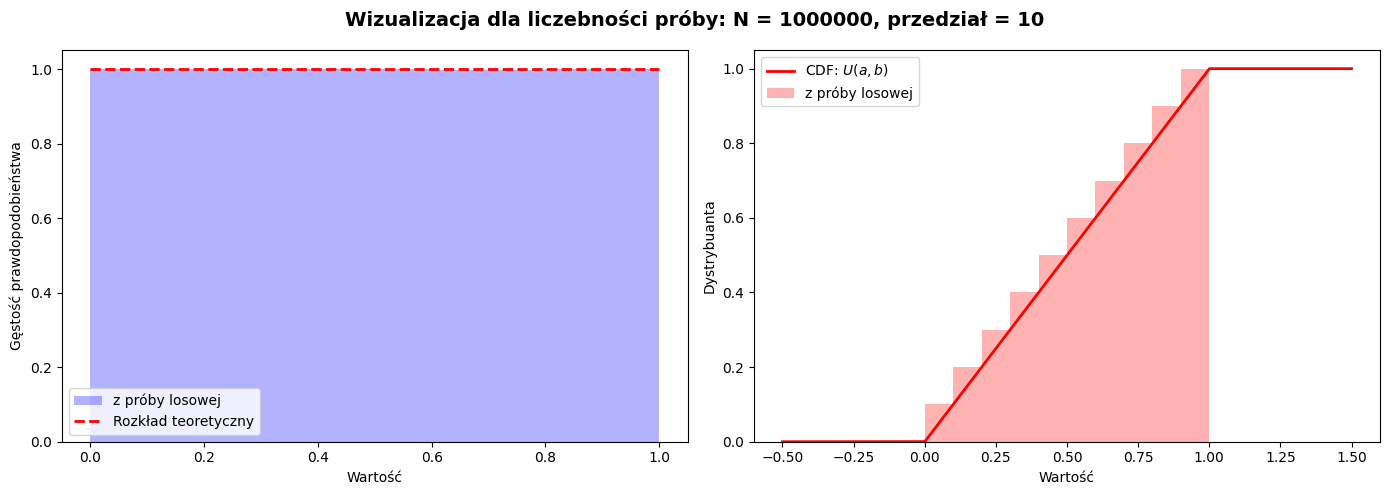

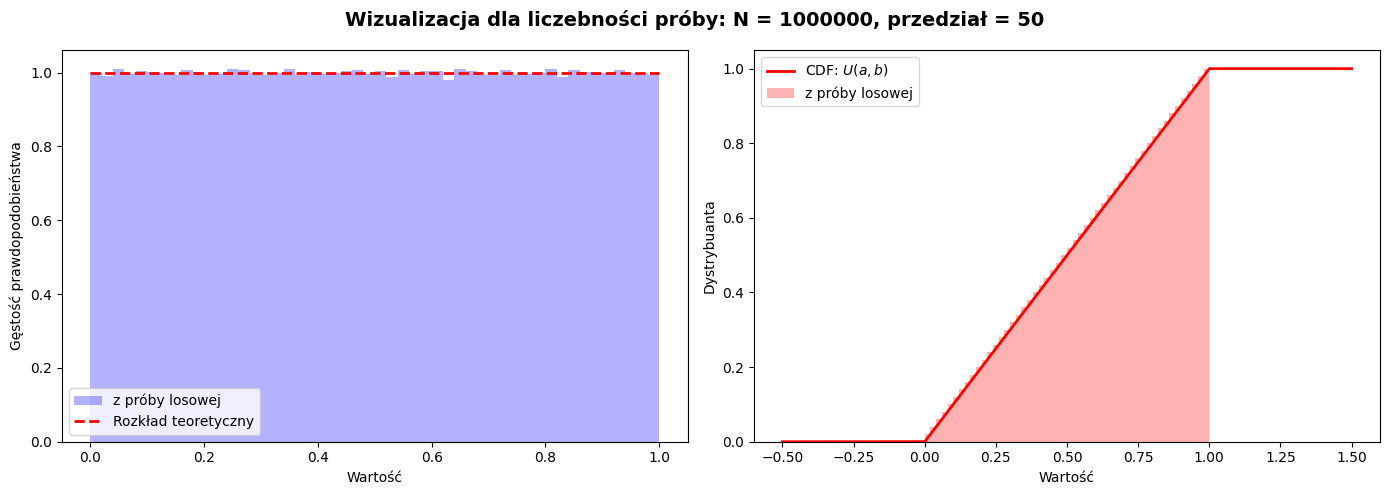

In [22]:
os.makedirs('./wykresy/', exist_ok=True)
wielkosci_prob = [100, 1000, 100000, 1_000_000]

for N in wielkosci_prob:
  nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"

  dane = np.loadtxt(nazwa_pliku, unpack=True)

  # Wartości teoretyczne wartości oczekiwanej i odchylenia standardowego.
  a = 0
  b = 1

  teoretyczny_x = [0, 1]
  teoretyczny_y = [1, 1]

  # Wartości na osi X histogramu.
  # dziedzina = np.arange(wart_oczek-3*odch_std, wart_oczek+3*odch_std, 0.1)
  # Teoretyczna funkcja gęstości prawdopodobieństwa rozkładu normalnego o zadanych parametrach.
  # fgp = norm.pdf(dziedzina, a, b)
  x = np.linspace(a - 0.5, b + 0.5, N)

  dystrybuanta = np.piecewise(x,
                   [x < a, (x >= a) & (x <= b), x > b],
                   [0.0, lambda x: (x - a) / (b - a), 1.0])
  # Rysujemy histogram częstości. Histogram liczebności uzyskalibyśmy przy 'normed=False'.
  # W nowszej wersji NumPy zamiast 'normed' używamy parametru 'density'.
  for bin in [10, 50]:
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Wizualizacja dla liczebności próby: N = {N}, przedział = {bin}", fontsize=14, fontweight='bold')
    axs[0].hist(dane, bins=bin, density=True, color='blue', alpha=0.3, label='z próby losowej')
    # Rysujemy również teoretyczną funkcję gęstości prawodpodobieństwa.
    axs[0].plot(teoretyczny_x, teoretyczny_y, 'r--', linewidth=2, label='Rozkład teoretyczny')
    axs[0].set_xlabel('Wartość')
    axs[0].set_ylabel('Gęstość prawdopodobieństwa')
    axs[0].legend(loc='best')

    # Teoretyczna dystrybuanta rozkładu normalnego o zadanych parametrach.
    # dystrybuanta = norm.cdf(dziedzina, wart_oczek, odch_std)
    # Dystrybuanta empiryczna, czyli histogram skumulowany ('cumulative=True').
    # Tym razem wymusiliśmy liczbę przedziałów 'bins'.
    axs[1].plot(x, dystrybuanta, 'r-', lw=2, label=r'CDF: $U(a, b)$')
    axs[1].hist(dane, bins=bin, density=True, color='red', alpha=0.3, cumulative=True, label='z próby losowej')
    # axs[1].plot(dziedzina, dystrybuanta, 'k-', label='teoretyczna')
    axs[1].set_xlabel('Wartość')
    axs[1].set_ylabel('Dystrybuanta')
    axs[1].legend(loc='best')
    fig.savefig(f"./wykresy/histogram_dystrybuanta_liczba_próbek_{N}_przedział_{bin}.pdf", format='pdf')

    plt.tight_layout()
    plt.show()

#### Wnioski:

- Zwiększenie liczebności próby (np. do 100000) powoduje, że kształt empirycznego histogramu znacznie lepiej dopasowuje się do płaskiej formy teoretycznego rozkładu równomiernego.  

- Zastosowanie dużej liczby przedziałów (np. 50) przy bardzo małej próbie (np. 100 liczb) skutkuje powstawaniem silnych fluktuacji w wysokości słupków, co zamazuje ogólny obraz rozkładu danych.  

- Zrozumienie relacji wizualnych wymaga odpowiedniego doboru szerokości przedziałów histogramu proporcjonalnie do ilości analizowanych punktów

- Dystrybuanta empiryczna (wynikająca z histogramu skumulowanego) cechuje się znacznie większą gładkością i mniejszymi skokami w porównaniu do standardowego histogramu gęstości.  

- Dla rozkładu jednostajnego na przedziale od 0 do 1, teoretyczna krzywa dystrybuanty przyjmuje postać idealnie prostej, diagonalnej funkcji rosnącej.  

- Użycie dystrybuanty jest w praktyce stabilniejszym narzędziem diagnostycznym pozwalającym ocenić, czy wygenerowane liczby rzeczywiście pochodzą z pożądanego rozkładu.

# Zadanie 2 Weryfikacja jakości generatorów za pomocą testu Chi-kwadrat

Opis: W tym etapie skrypt tworzy zestawy wykresów, które zestawiają obok siebie histogramy odwzorowujące gęstość prawdopodobieństwa oraz histogramy skumulowane, pełniące funkcję dystrybuanty empirycznej. Dane z próby losowej zestawiane są z krzywymi teoretycznymi dla poszczególnych wielkości losowań

Generowanie 100 liczb...

----------------------------------------
Wyniki testu dla k = 11 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 8.9000
  P-wartość:           0.541620
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 100)


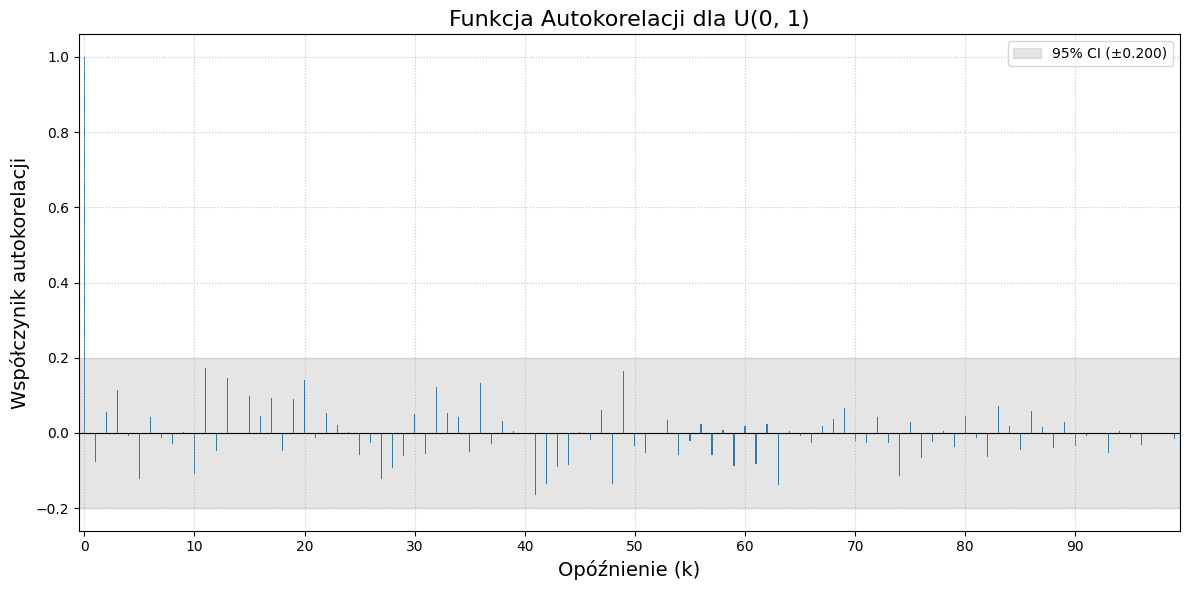

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 4.5000
  P-wartość:           0.921986
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 100)


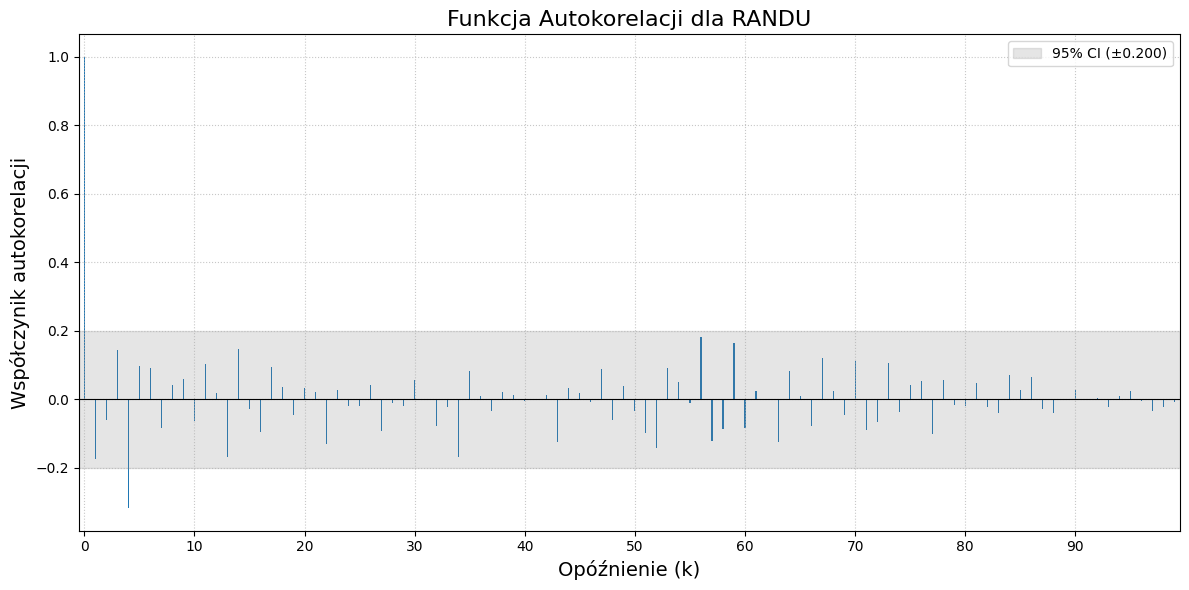


----------------------------------------
Wyniki testu dla k = 51 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 45.8600
  P-wartość:           0.640132
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 100)


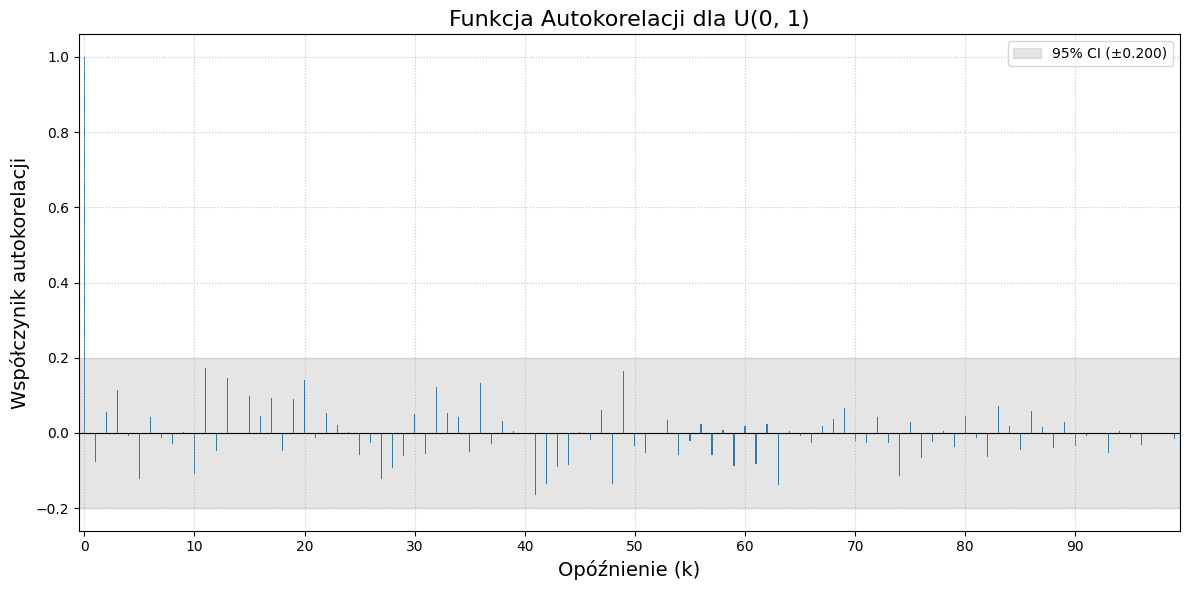

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 45.8600
  P-wartość:           0.640132
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 100)


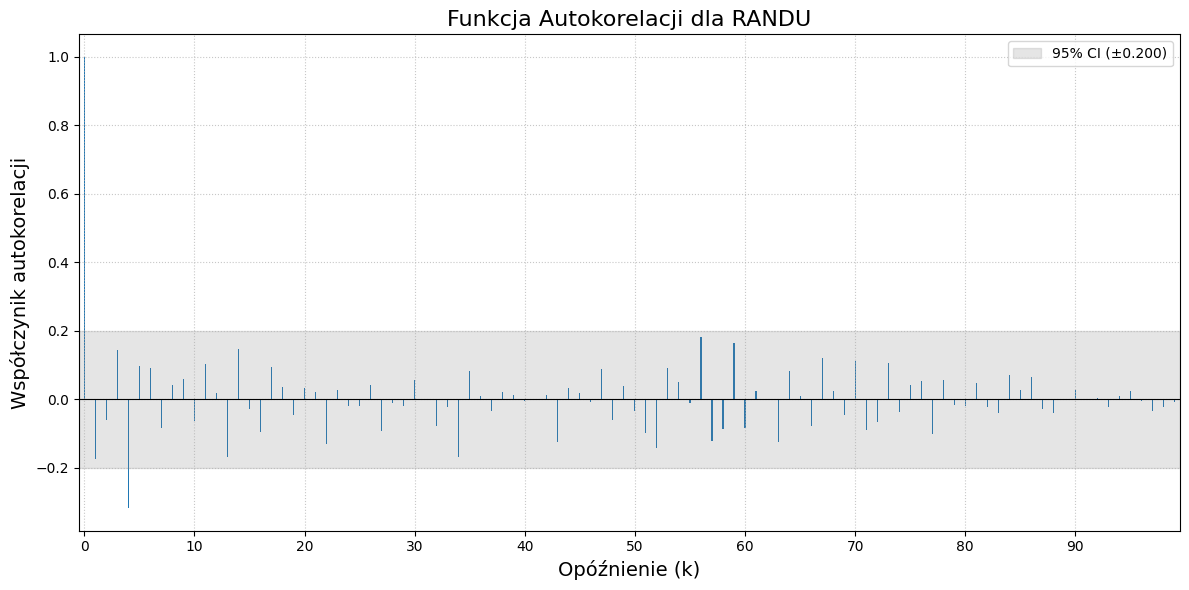


----------------------------------------
Wyniki testu dla k = 101 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 97.9600
  P-wartość:           0.539034
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 100)


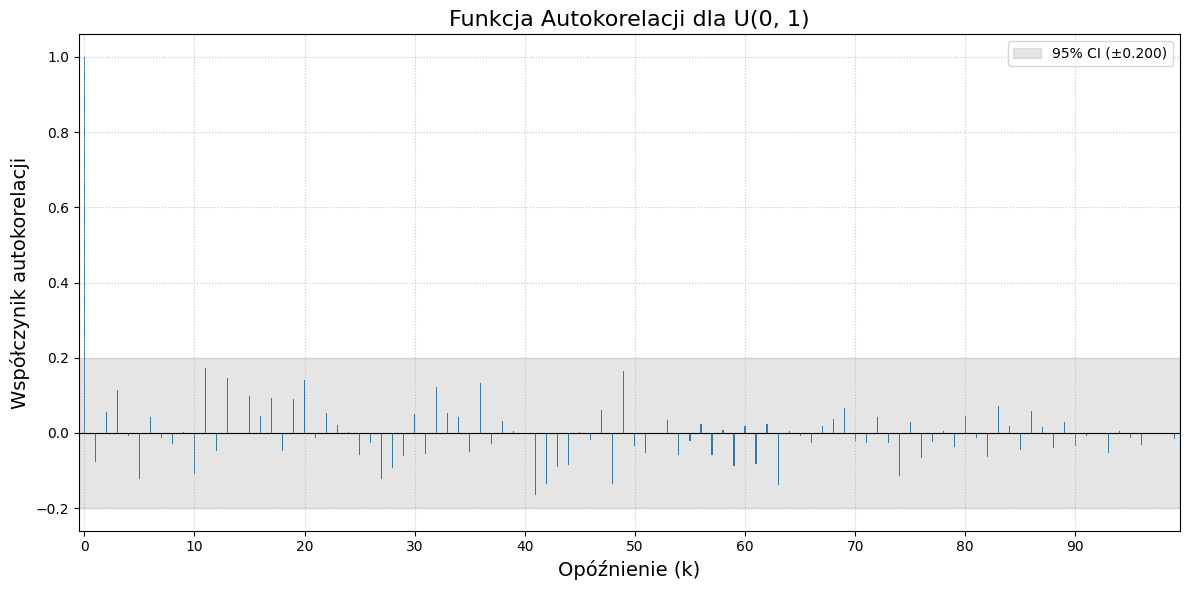

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 106.0400
  P-wartość:           0.320710
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 100)


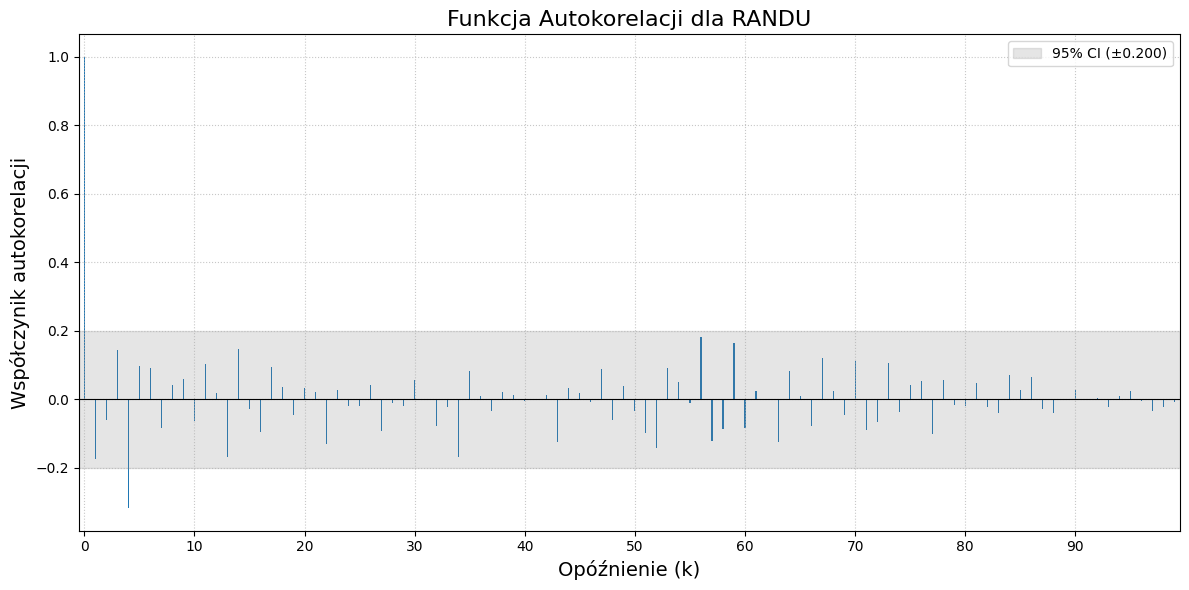

Generowanie 1000 liczb...

----------------------------------------
Wyniki testu dla k = 11 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 19.1940
  P-wartość:           0.037867
  Werdykt (p >= 0.05): NIEZGODNY (odrzucamy hipotezę)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 1000)


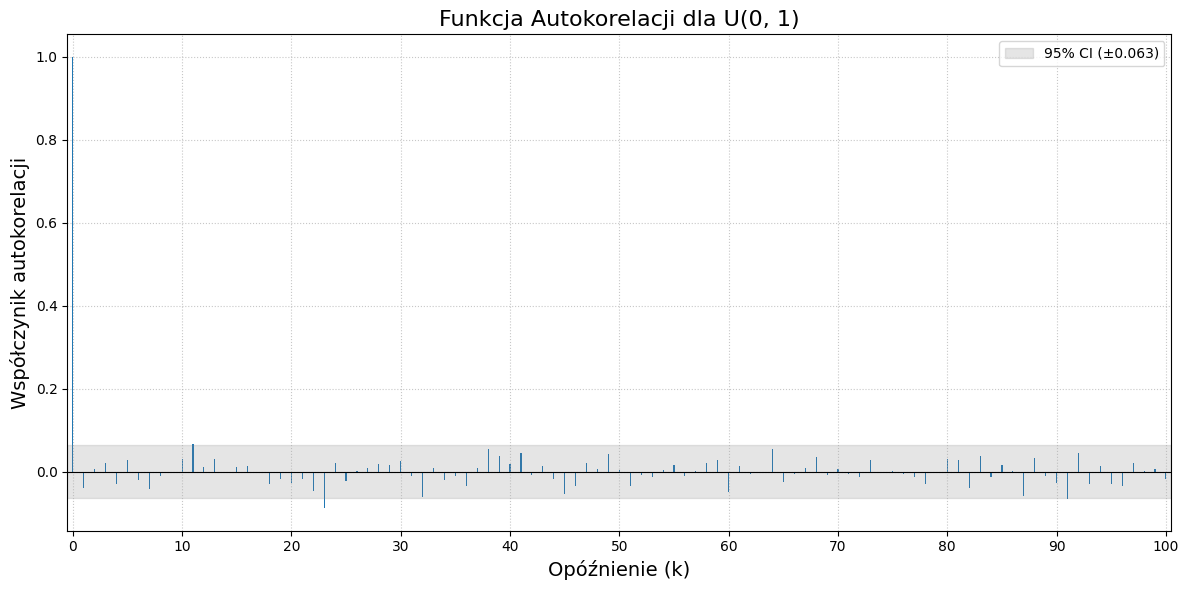

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 5.4220
  P-wartość:           0.861267
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 1000)


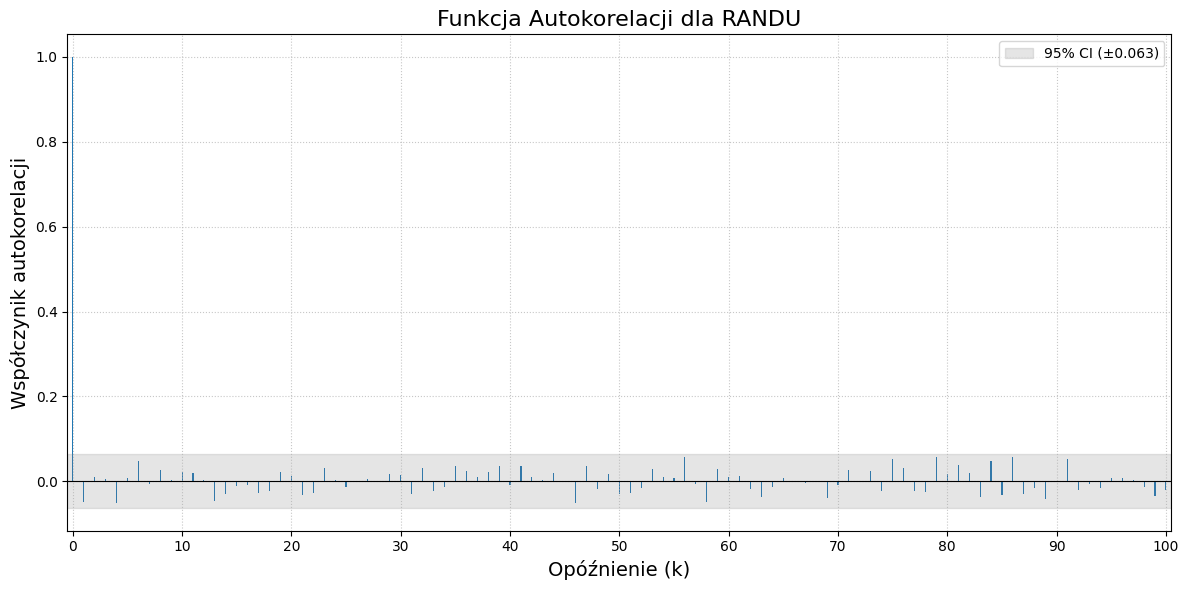


----------------------------------------
Wyniki testu dla k = 51 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 54.4760
  P-wartość:           0.308133
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 1000)


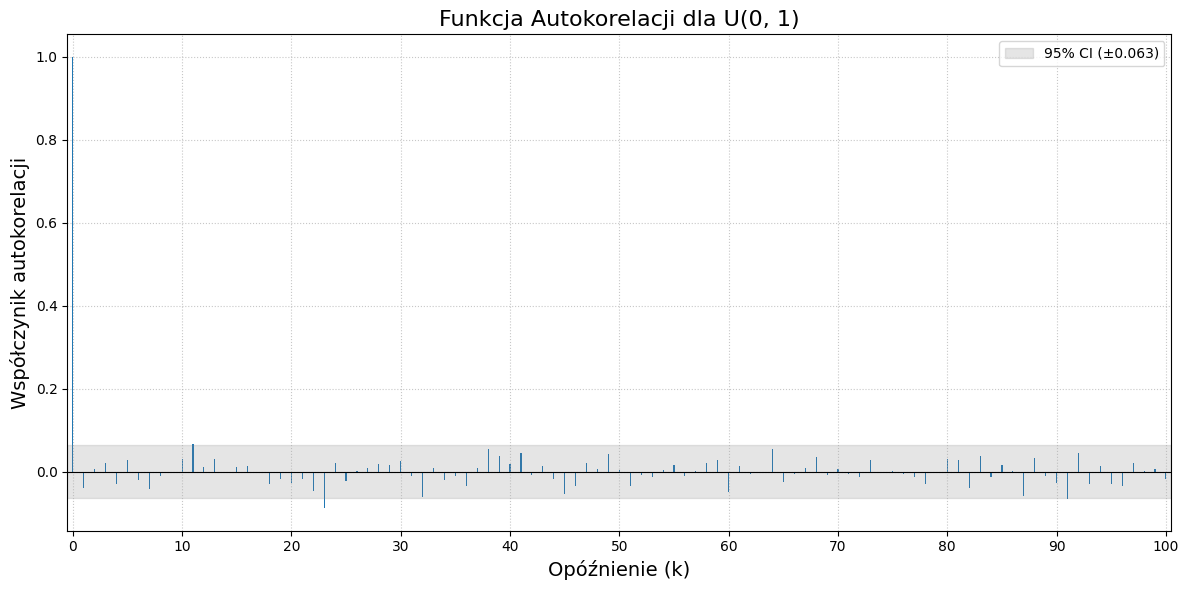

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 47.1320
  P-wartość:           0.589175
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 1000)


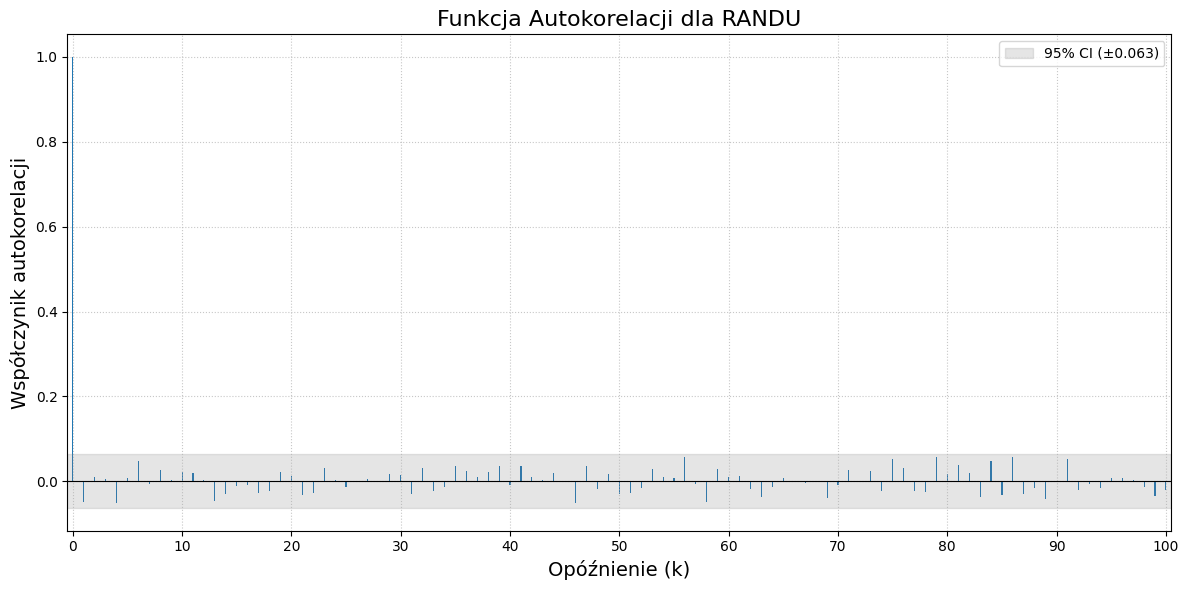


----------------------------------------
Wyniki testu dla k = 101 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 120.8980
  P-wartość:           0.076052
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 1000)


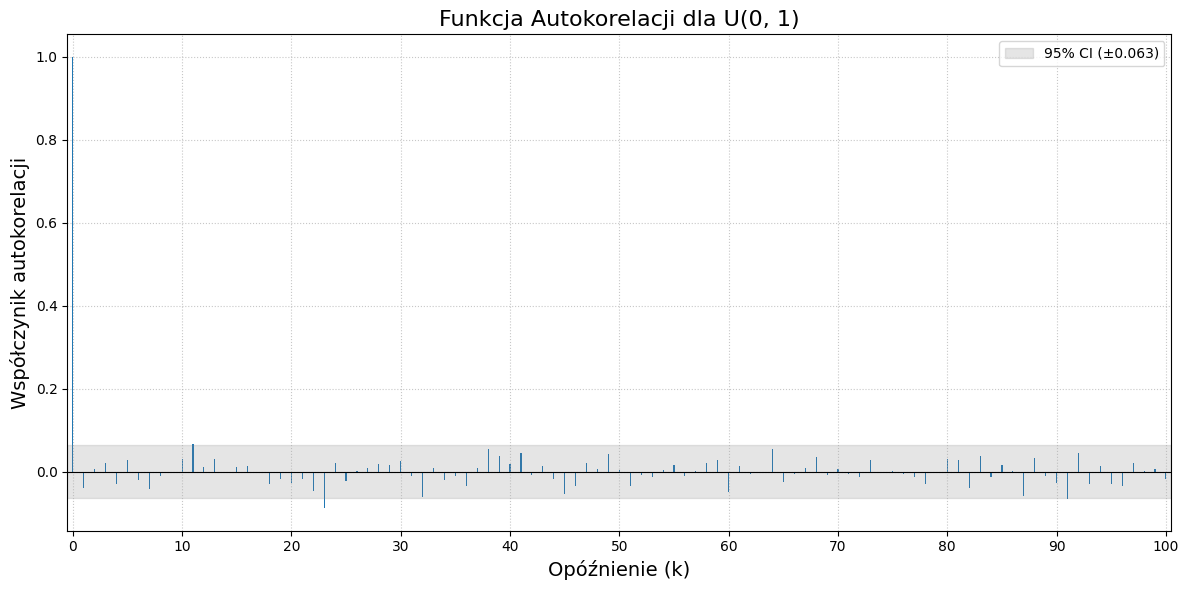

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 101.3040
  P-wartość:           0.444756
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 1000)


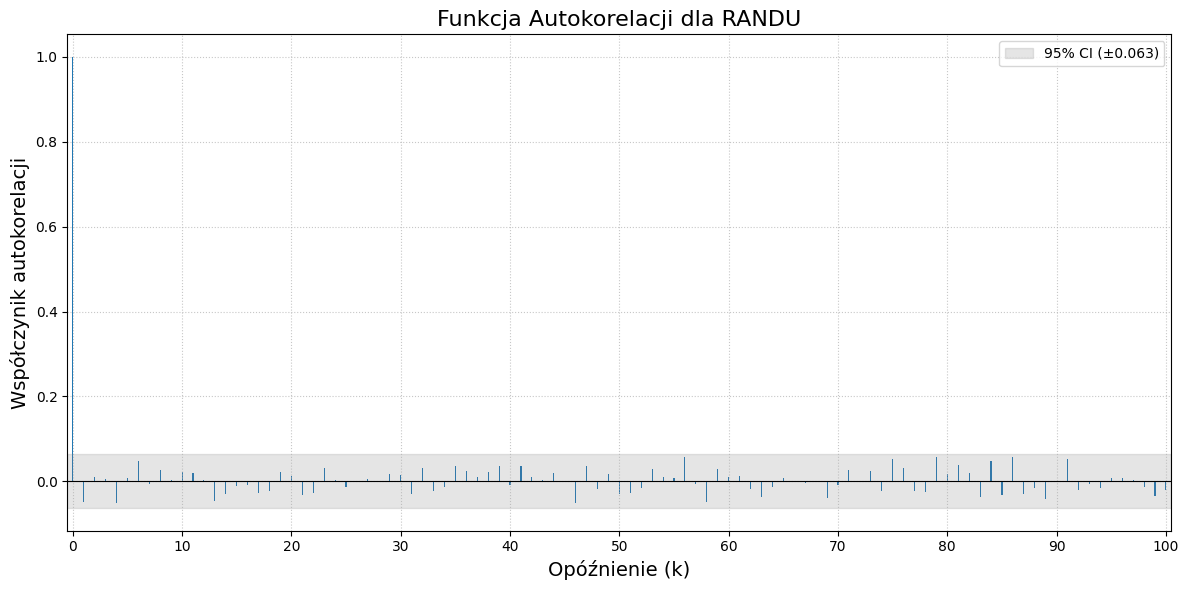

Generowanie 100000 liczb...

----------------------------------------
Wyniki testu dla k = 11 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 9.5600
  P-wartość:           0.479907
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 100000)


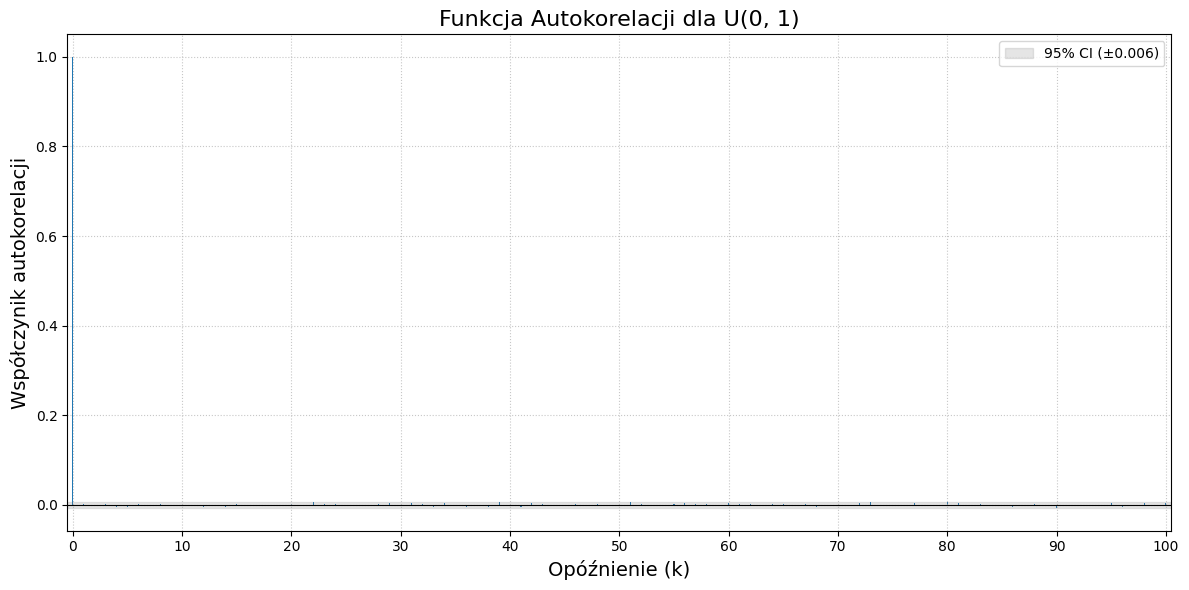

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 9.7892
  P-wartość:           0.459176
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 100000)


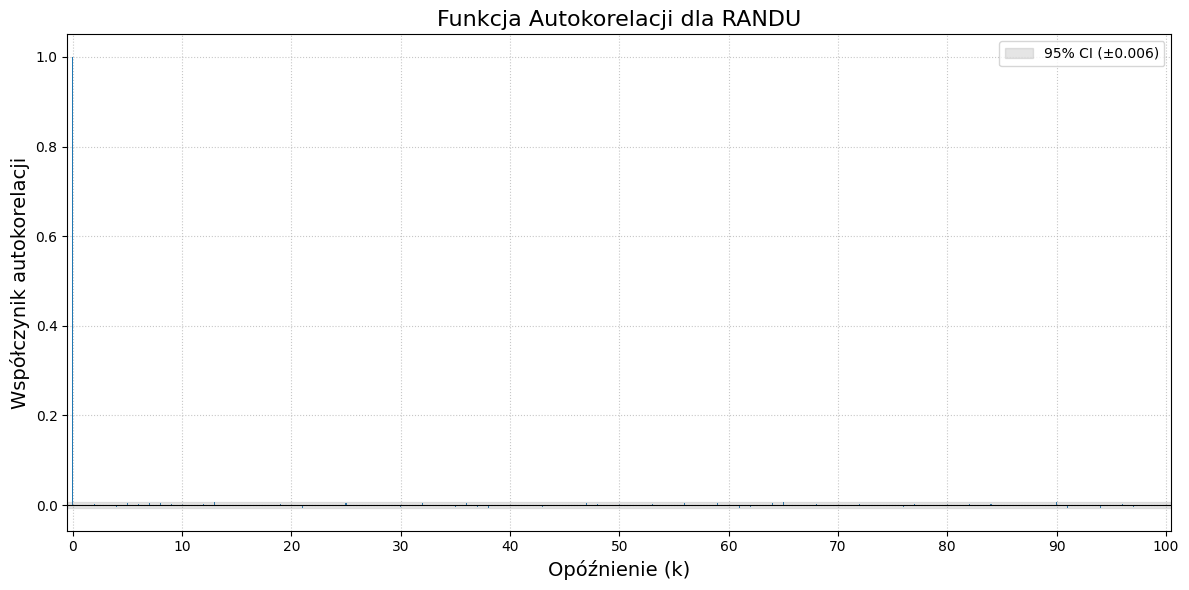


----------------------------------------
Wyniki testu dla k = 51 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 38.1779
  P-wartość:           0.889273
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 100000)


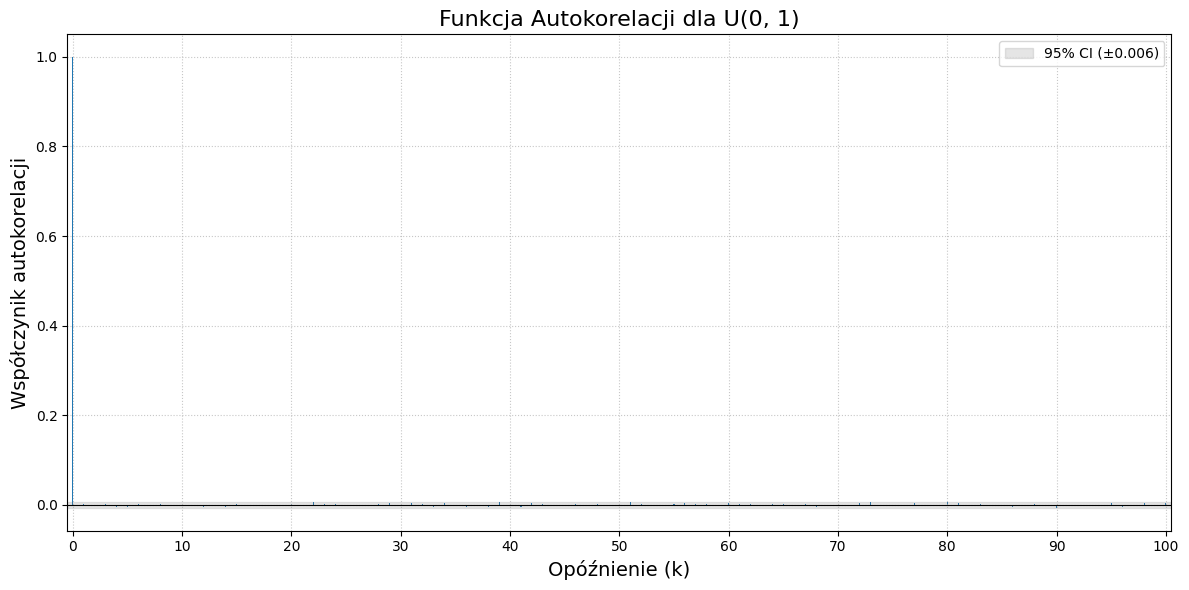

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 55.8667
  P-wartość:           0.263927
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 100000)


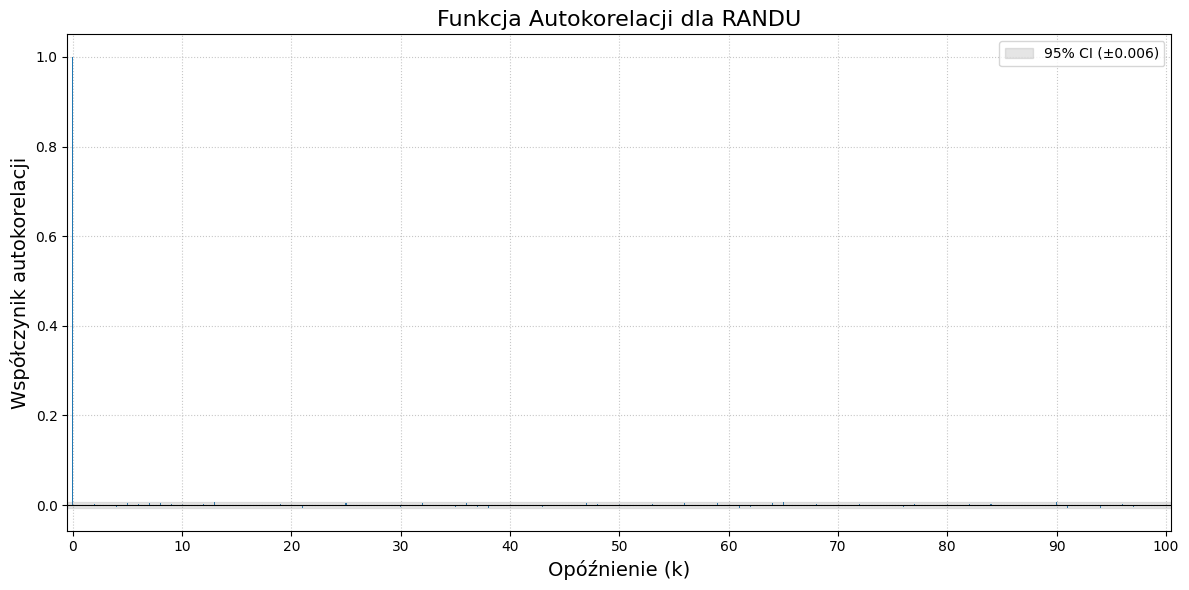


----------------------------------------
Wyniki testu dla k = 101 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 82.8756
  P-wartość:           0.892508
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 100000)


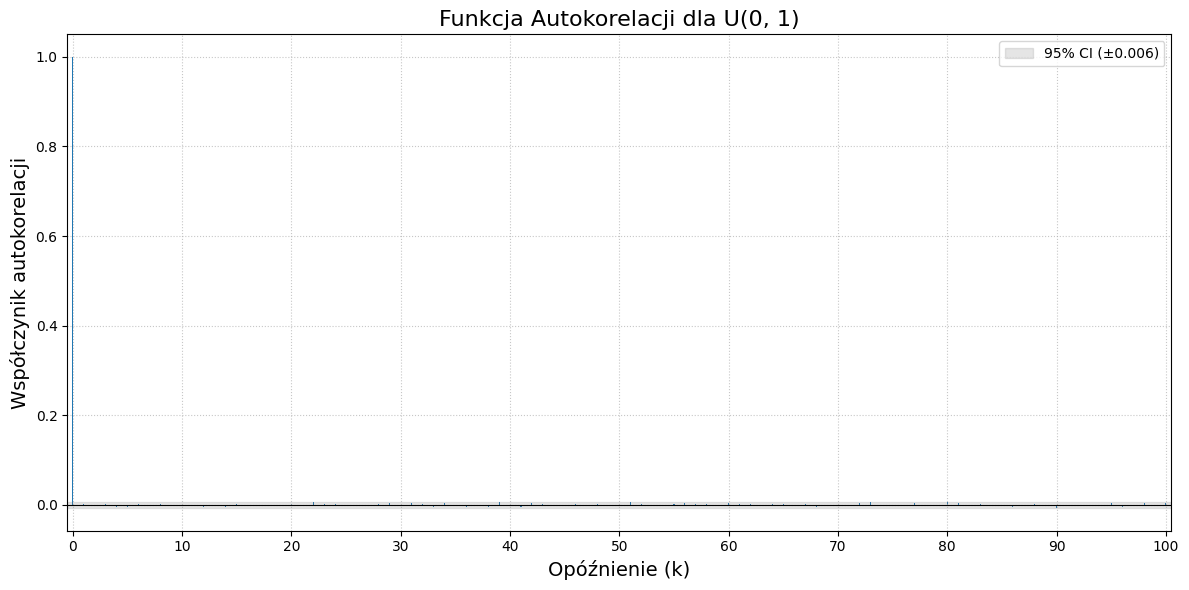

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 130.6950
  P-wartość:           0.021315
  Werdykt (p >= 0.05): NIEZGODNY (odrzucamy hipotezę)
Obliczanie autokorelacji dla RANDU (długość sekwencji 100000)


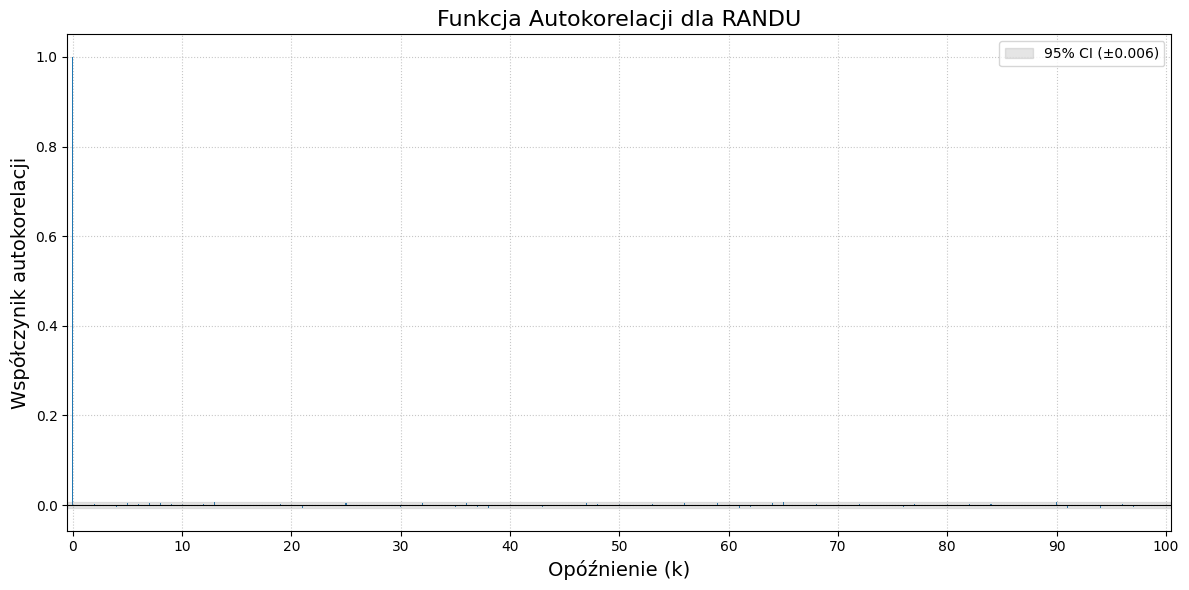

Generowanie 1000000 liczb...

----------------------------------------
Wyniki testu dla k = 11 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 0.9047
  P-wartość:           0.999891
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 1000000)


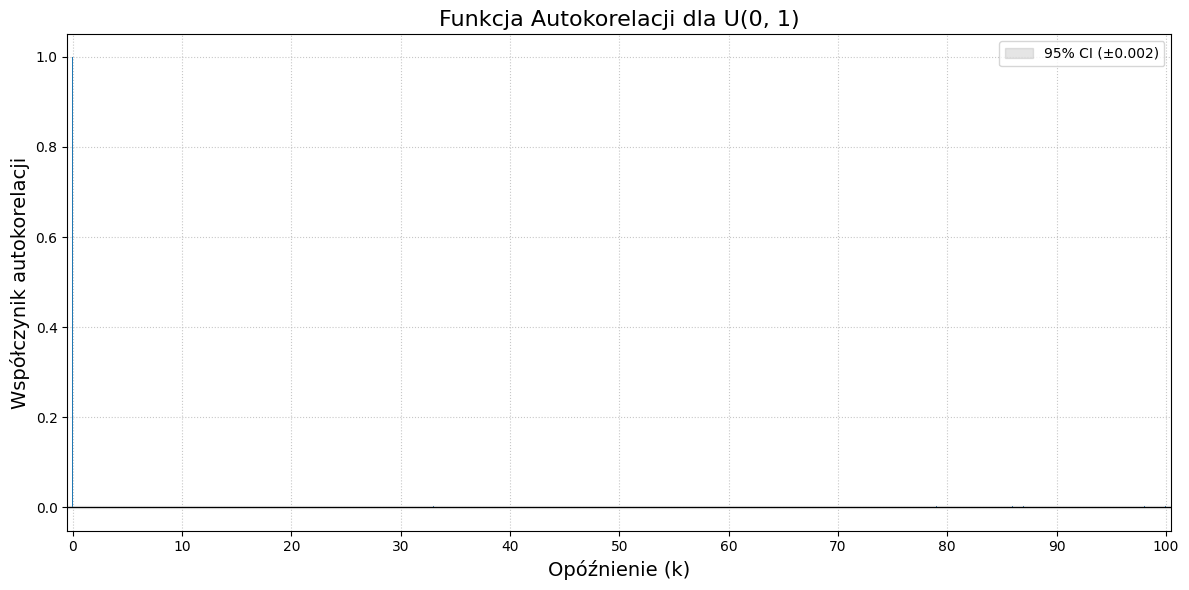

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 4.1836
  P-wartość:           0.938684
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 1000000)


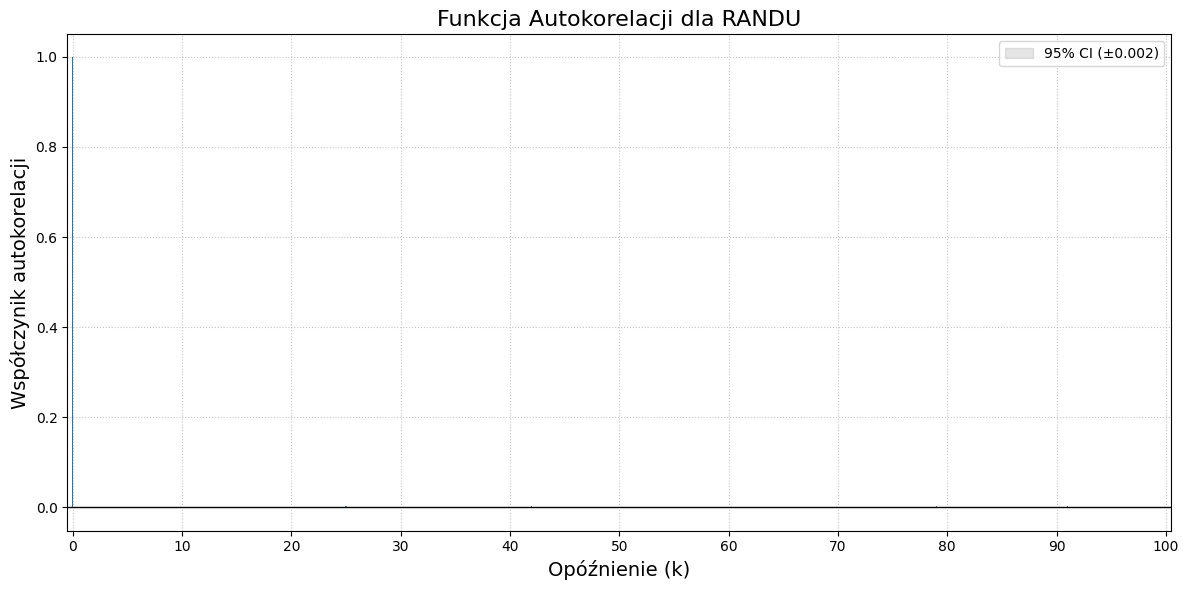


----------------------------------------
Wyniki testu dla k = 51 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 48.6929
  P-wartość:           0.525910
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 1000000)


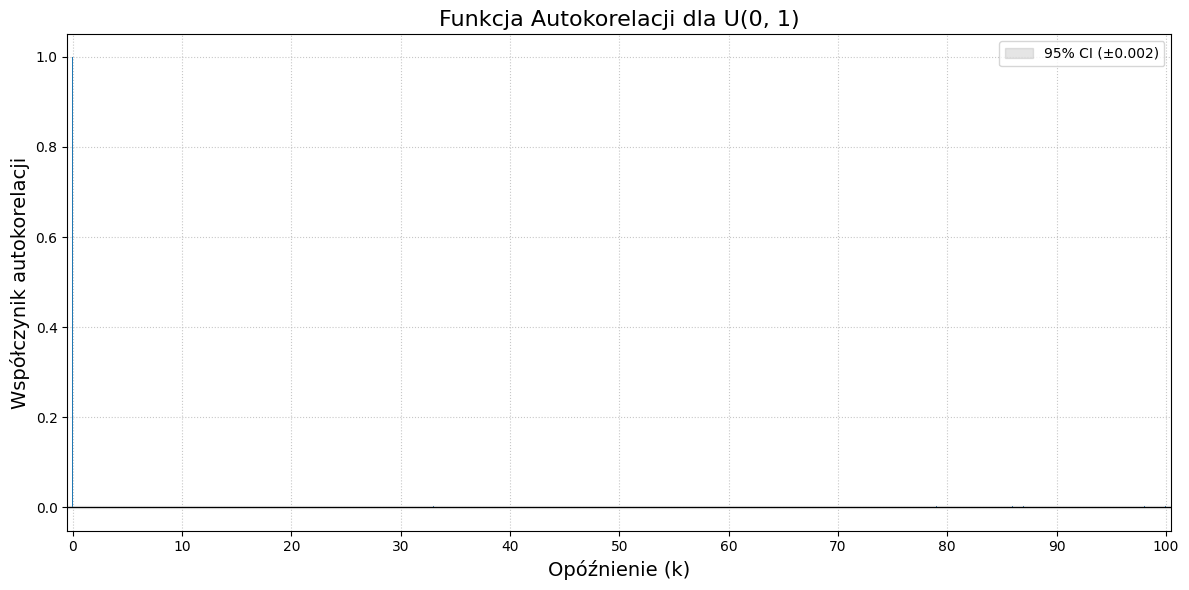

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 43.5060
  P-wartość:           0.729857
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 1000000)


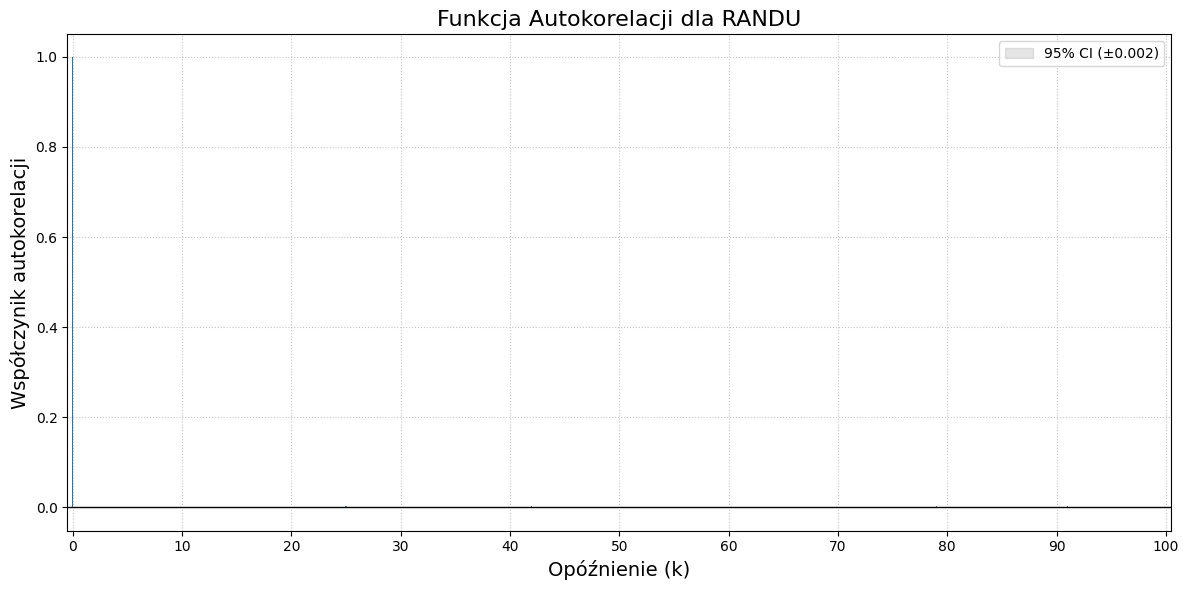


----------------------------------------
Wyniki testu dla k = 101 przedziałów:
----------------------------------------
Generator DOBRY (NumPy):
  Wartość Chi-kwadrat: 89.2795
  P-wartość:           0.770162
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)

Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji 1000000)


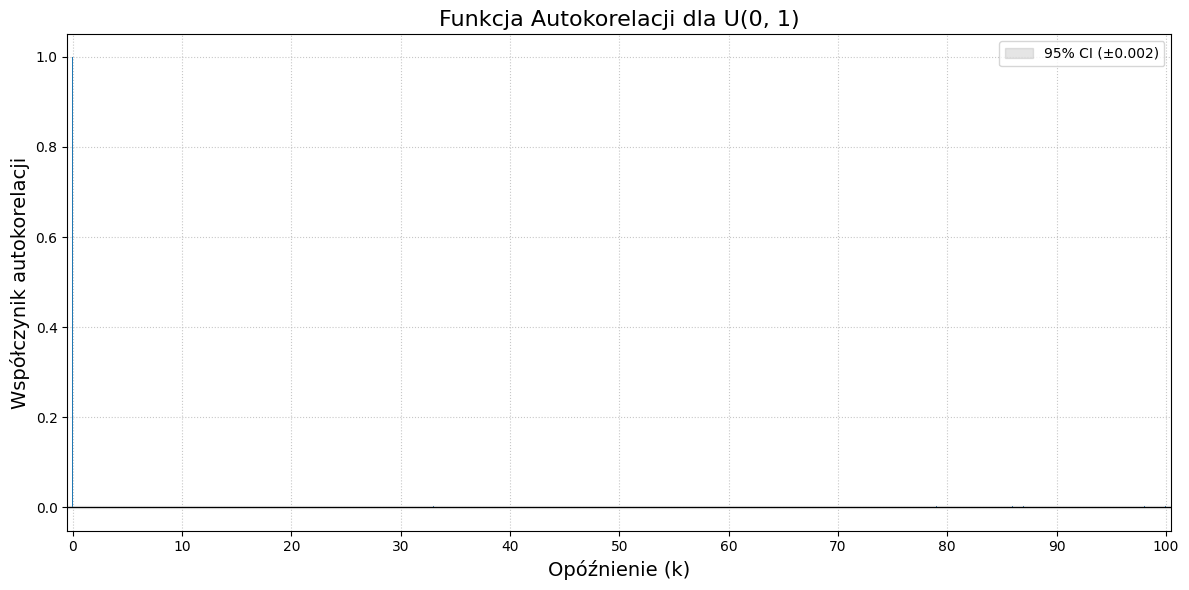

Generator ZŁY (RANDU):
  Wartość Chi-kwadrat: 109.4300
  P-wartość:           0.243927
  Werdykt (p >= 0.05): ZGODNY z rozkładem U(0,1)
Obliczanie autokorelacji dla RANDU (długość sekwencji 1000000)


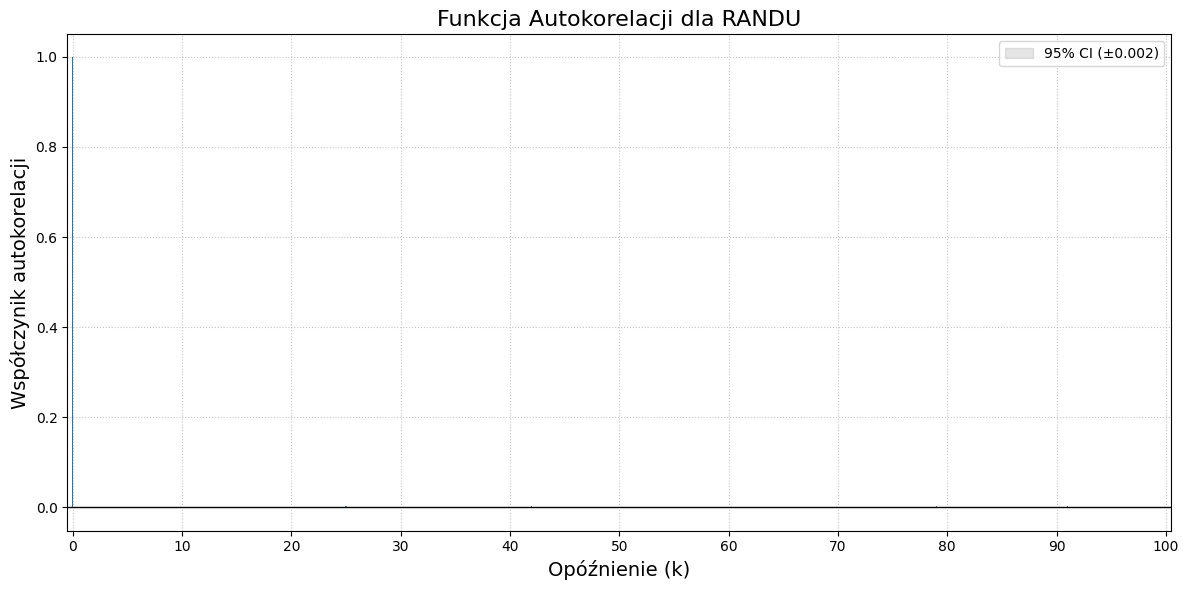

In [27]:
def generator_zly_randu(n_samples, seed=12345):
    """
    Implementacja 'złego' generatora typu LCG (Linear Congruential Generator).
    Używamy klasycznych parametrów dla generatora RANDU (a=65539, c=0, m=2**31).
    Zwraca wartości znormalizowane do przedziału [0, 1).
    """
    a = 65539
    c = 0
    m = 2**31
    X = seed

    # Tworzymy pustą tablicę na wyniki
    results = np.zeros(n_samples)

    for i in range(n_samples):
        X = (a * X + c) % m
        results[i] = X / m

    return results

def test_chi_kwadrat(dane, k):
    """
    Oblicza statystykę chi-kwadrat ze wzoru uproszczonego oraz p-wartość.
    """
    n = len(dane)

    # Zliczamy ile liczb wpadło do każdego z k przedziałów w zakresie [0, 1]
    n_i, _ = np.histogram(dane, bins=k, range=(0.0, 1.0))

    # Implementacja uproszczonego wzoru z zadania: (k / n) * sum(n_i**2) - n
    chi_kwadrat_stat = (k / n) * np.sum(n_i**2) - n

    # Obliczamy liczbę stopni swobody
    df = k - 1

    # Obliczamy p-wartość.
    # scipy.stats.chi2.sf to "survival function" (1 - dystrybuanta CDF),
    # co pozwala uzyskać pole pod prawym ogonem rozkładu.
    p_wartosc = chi2.sf(chi_kwadrat_stat, df)

    return chi_kwadrat_stat, p_wartosc

# ==========================================
# GŁÓWNA CZĘŚĆ PROGRAMU
# ==========================================

n_losowan = 100000  # Liczebność próby losowej
przedzialy_k = [11, 51, 101] # Badane wartości k z zadania
wielkosci_prob = [100, 1000, 100000, 1_000_000]
max_lag_to_plot = 100

for N in wielkosci_prob:
  nazwa_pliku = nazwa_pliku_prefix + str(N) + ".txt"

  dane = np.loadtxt(nazwa_pliku, unpack=True)

  print(f"Generowanie {N} liczb...")
  # 'Dobry' generator: standardowy generator liczb pseudolosowych z NumPy
  dane_dobre = dane
  # 'Zły' generator: nasza implementacja RANDU
  dane_zle = generator_zly_randu(len(dane))
  # for nazwa_pliku in []
  for k in przedzialy_k:
      print(f"\n{'-'*40}")
      print(f"Wyniki testu dla k = {k} przedziałów:")
      print(f"{'-'*40}")

      # 1. Test dobrego generatora
      stat_dobry, p_dobry = test_chi_kwadrat(dane_dobre, k)
      wynik_dobry = "ZGODNY z rozkładem U(0,1)" if p_dobry >= 0.05 else "NIEZGODNY (odrzucamy hipotezę)"

      print("Generator DOBRY (NumPy):")
      print(f"  Wartość Chi-kwadrat: {stat_dobry:.4f}")
      print(f"  P-wartość:           {p_dobry:.6f}")
      print(f"  Werdykt (p >= 0.05): {wynik_dobry}\n")

      # Obliczanie autokorelacji dla U(0, 1)
      print(f"Obliczanie autokorelacji dane wygenerowane U(0, 1) (długość sekwencji {len(dane_dobre)})")
      acorr_u = calculate_autocorrelation(dane_dobre, max_lag=max_lag_to_plot)
      plot_autocorrelation(acorr_u, 'Funkcja Autokorelacji dla U(0, 1)', len(dane_dobre), max_lag_to_plot)

      # 2. Test złego generatora
      stat_zly, p_zly = test_chi_kwadrat(dane_zle, k)
      wynik_zly = "ZGODNY z rozkładem U(0,1)" if p_zly >= 0.05 else "NIEZGODNY (odrzucamy hipotezę)"

      print("Generator ZŁY (RANDU):")
      print(f"  Wartość Chi-kwadrat: {stat_zly:.4f}")
      print(f"  P-wartość:           {p_zly:.6f}")
      print(f"  Werdykt (p >= 0.05): {wynik_zly}")


      # Obliczanie autokorelacji dla RANDU
      print(f"Obliczanie autokorelacji dla RANDU (długość sekwencji {len(dane_zle)})")
      acorr_randu = calculate_autocorrelation(dane_zle, max_lag=max_lag_to_plot)
      plot_autocorrelation(acorr_randu, 'Funkcja Autokorelacji dla RANDU', len(dane_zle), max_lag_to_plot)

### Wnioski:

- Nowoczesne generatory pseudolosowe (jak ten stosowany domyślnie w bibliotece NumPy) pomyślnie przechodzą rygorystyczny test Chi-kwadrat, uzyskując wartość parametru p powyżej granicy 0.05.  

- Stare konstrukcje algorytmiczne typu LCG, w tym wariant RANDU, posiadają wady matematyczne sprawiające, że test odrzuca hipotezę o ich zgodności z rozkładem równomiernym.  

- Modyfikacja liczby badanych przedziałów (parametru k) zmienia liczbę stopni swobody testu, co ma bezpośredni wpływ na jego czułość i ostateczny werdykt odnośnie wadliwych generatorów.

### Zadanie 3 Estymacja wartości liczby pi metodą całkowania Monte Carlo

Opis: Ostatnie zadanie implementuje metodę całkowania zwaną "orzeł-reszka" (hit-or-miss), gdzie skrypt losuje do miliona punktów na obszarze kwadratu i na podstawie ilości trafień we wpisane w niego koło wylicza wartość liczby pi. Wyliczona w ten sposób estymata wraz z przypisanymi jej słupkami błędu wynikającymi z odchylenia standardowego jest prezentowana na specjalnym wykresie wykorzystującym logarytmiczną skalę osi X.

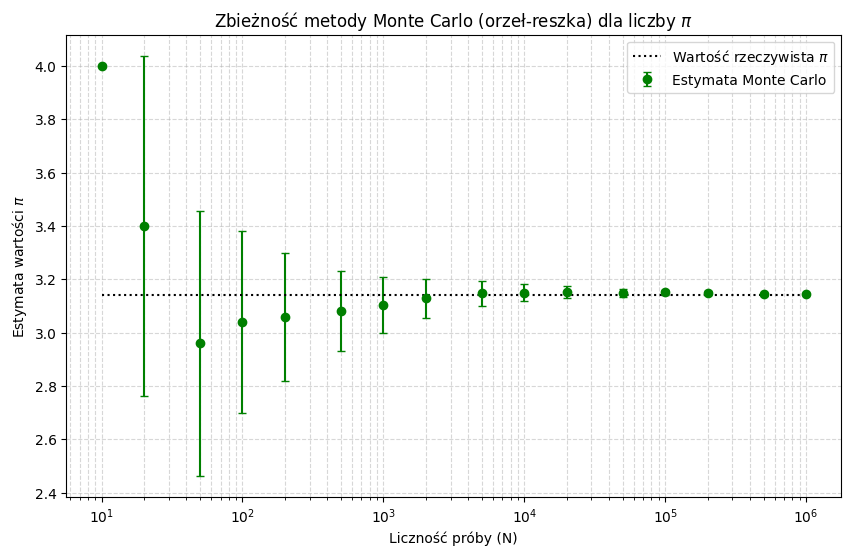

In [24]:
# 1. Przygotowanie folderów na dane i wykresy, aby skrypt nie rzucił błędu
os.makedirs('./dane', exist_ok=True)

# 2. GENERACJA DANYCH MONTE CARLO
N_max = 1000000  # Maksymalna liczba prób
V = 4.0          # Powierzchnia obszaru próbkowania (kwadrat od -1 do 1 ma pole 4)

# Losujemy wszystkie punkty z góry (wektoryzacja dla szybkości)
x = np.random.uniform(-1, 1, N_max)
y = np.random.uniform(-1, 1, N_max)

# Tablica logiczna - czy punkt trafił do wnętrza koła (promień <= 1)
trafienia = (x**2 + y**2) <= 1.0

# Kroki logarytmiczne, dla których chcemy zapisywać wyniki
kroki_n = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000,
           20000, 50000, 100000, 200000, 500000, 1000000]

wyniki = []

for n in kroki_n:
    # Zliczamy sukcesy (M) dla danej próby n
    M = np.sum(trafienia[:n])

    # Estymata wyniku (PI)
    estymata_pi = V * (M / n)

    # Odchylenie standardowe ze wzoru podanego w zadaniu
    # sd = V * sqrt( (1/N) * (M/N) * (1 - M/N) )
    sd = V * np.sqrt((1.0 / n) * (M / n) * (1.0 - (M / n)))

    wyniki.append((n, estymata_pi, sd))

# 3. ZAPIS DO PLIKU (3 kolumny: N, estymata, odchylenie)
# fmt='%d %.6f %.6f' formatuje N jako int, a resztę jako float z 6 miejscami po przecinku
np.savetxt('./dane/slupki_bledu.txt', wyniki, fmt='%d %.6f %.6f')


# 4. RYSOWANIE WYKRESU (na bazie Twojego kodu)

# n  - liczność próby Monte-Carlo,
# y  - estymata obliczanej wartości (w tym wypadku Pi),
# sd - estymata odchylenia standardowego 'y'.
n, y_est, sd = np.loadtxt('./dane/slupki_bledu.txt', unpack=True)

plt.figure(figsize=(10, 6)) # Nieco większy wykres dla czytelności

# Składnia jak dla 'plot', ale trzeci argument (yerr) to wysokość pionowego
# słupka błędu, obrazującego niepewność wyznaczania estymaty.
# Obszar pomiędzy górnym i dolnym słupkiem błędu to przedział ufności 95%
plt.errorbar(n, y_est, yerr=2*sd, fmt='go', label='Estymata Monte Carlo', capsize=3)

# Rzeczywista wartość PI. Wykreślamy ją linią punktową,
# biegnącą przez cały zakres zmienności argumentu 'n'.
plt.plot([min(n), max(n)], [np.pi, np.pi], 'k:', label='Wartość rzeczywista $\\pi$')

# Skala logarytmiczna na osi X jest konieczna.
plt.xscale('log')
plt.xlabel('Liczność próby (N)')
plt.ylabel('Estymata wartości $\\pi$')
plt.title('Zbieżność metody Monte Carlo (orzeł-reszka) dla liczby $\\pi$')
plt.legend(loc='best')
plt.grid(True, which="both", ls="--", alpha=0.5) # Dodatkowa siatka pomocnicza

plt.savefig('./wykresy/przedzialy.pdf', format='pdf')
plt.show()

### Wnioski
- Algorytmy typu Monte Carlo pozwalają skutecznie oszacować niewiadomą (tu liczbę pi), lecz ich trafność zbliża się do prawdziwej wartości matematycznej jedynie przy ogromnych ilościach prób.  

- Zasięg słupków błędu widocznych na wygenerowanym wykresie systematycznie ulega zwężeniu w miarę jak rośnie pula wylosowanych punktów.  

- Użycie skali logarytmicznej na wykresie zbieżności jest absolutnie kluczowe, ponieważ unaocznia, że uzyskanie precyzyjniejszych wyników kosztuje skokowo więcej zasobów obliczeniowych i kolejnych dziesiątek tysięcy losowań